In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor, as_completed
from ant.market import Market
from ant.decentralised.dynamic import COAPAgent
from ant.decentralised.direct import ProportionalAgent
from ant.centralised import P4
from ant.decentralised.utility import create_grid_graph

In [2]:
# --- Configuration ---
NUM_SEEDS = 10
MARKET_SIZE = 80
SIMULATION_DURATION = 50
WINDOW_START = 0
WINDOW_END = min(SIMULATION_DURATION, 50)

KS = [1, 2]
BENCHMARKS = ["Proportional"] 
TARGET_AGENTS = ["COAP"]

# Number of parallel workers (threads)
NUM_WORKERS = 8


In [3]:
# --- Helper: Create Graphs with Specific Seed ---
def create_graphs(n, seed):
    graphs = {
        "Fully Connected": nx.complete_graph(n),
        "Random": nx.gnp_random_graph(n, 0.1, seed=seed),
        "Grid": create_grid_graph(n),
        "Small-World": nx.watts_strogatz_graph(n, int(n / 2), 0.05, seed=seed),
    }
    if not nx.is_connected(graphs["Random"]):
        return create_graphs(n, seed + NUM_SEEDS)
    return graphs

In [4]:
# --- Worker Function (Runs ONE Seed) ---
def run_single_seed(seed_idx):
    """
    Runs the entire simulation logic for a single seed index.
    Returns a dictionary of results for this specific seed.
    """
    current_seed = seed_idx
    
    # Generate topologies for this seed
    graphs = create_graphs(MARKET_SIZE, seed=current_seed)
    
    seed_results = {}
    seed_crashes = {}
    
    for graph_type, graph_obj in graphs.items():
        # Initialize the structure for this graph type explicitly
        # This ensures "COAP" and Benchmarks keys exist
        seed_results[graph_type] = {
            "COAP": {k: None for k in KS},  # Pre-initialize with None or empty lists
            **{b: {None: None} for b in BENCHMARKS}
        }
        seed_crashes[graph_type] = {
            "COAP": {k: None for k in KS},
            **{b: {None: None} for b in BENCHMARKS}
        }
        
        # Run COAP
        for k in KS:
            _market = Market(
                MARKET_SIZE,
                graph=graph_obj,
                seed=current_seed,
                agent_type=COAPAgent,
                resource_volatility=0.01,
                k=k,
                report_crashes=True,
            )
            
            optimal_allocations, utility_vector = P4(_market)
            _market.set_market_equilibrium(optimal_allocations, utility_vector)

            sim_result = _market.simulate(
                SIMULATION_DURATION, 
                use_average_in_market_loss=True, 
                return_utility_instead_of_market_loss=False
            )
            
            window_data = sim_result[WINDOW_START:WINDOW_END]
            
            crash_count = sum([1 if agent.has_crashed else 0 for agent in _market.agents])
            health_rate = 1.0 - (crash_count / len(_market.agents))
            
            # Now this assignment works because keys were pre-initialized above
            seed_results[graph_type]["COAP"][k] = window_data
            seed_crashes[graph_type]["COAP"][k] = health_rate

        # Run Benchmarks
        for b_agent in BENCHMARKS:
            agent_type = ProportionalAgent if b_agent == "Proportional" else None
            
            if agent_type:
                _market = Market(
                    MARKET_SIZE,
                    graph=graph_obj,
                    seed=current_seed,
                    agent_type=agent_type,
                )
                
                optimal_allocations, utility_vector = P4(_market)
                _market.set_market_equilibrium(optimal_allocations, utility_vector)
                
                sim_result = _market.simulate(
                    SIMULATION_DURATION, 
                    use_average_in_market_loss=True, 
                    return_utility_instead_of_market_loss=False
                )
                
                window_data = sim_result[WINDOW_START:WINDOW_END]
                
                # Accessing pre-initialized keys
                seed_results[graph_type][b_agent][None] = window_data
                seed_crashes[graph_type][b_agent][None] = 1.0 

    return {"seed_idx": seed_idx, "data": seed_results, "crashes": seed_crashes}

In [5]:
# --- Data Aggregation Containers ---
results_store = {}
crash_rates_store = {}

graph_types = ["Fully Connected", "Random", "Grid", "Small-World"]
for gt in graph_types:
    results_store[gt] = {
        "COAP": {k: [] for k in KS},
        **{b: {None: []} for b in BENCHMARKS}
    }
    crash_rates_store[gt] = {
        "COAP": {k: [] for k in KS},
        **{b: {None: []} for b in BENCHMARKS}
    }


In [6]:
# --- Main Simulation Loop over 30 Seeds ---
print(f"Starting simulation loop for {NUM_SEEDS} seeds with dynamic topologies...")

for seed_idx in range(NUM_SEEDS):
    # Use the same seed index for both the Agent randomness AND the Graph generation
    current_seed = seed_idx 
    
    # 1. Generate NEW Topologies for this specific seed
    graphs = create_graphs(MARKET_SIZE, seed=current_seed)

    for graph_type, graph_obj in graphs.items():
        # 2. Run COAP Agents
        for k in KS:
            _market = Market(
                MARKET_SIZE,
                graph=graph_obj,
                seed=current_seed,        # Seed for agents/resources
                agent_type=COAPAgent,
                resource_volatility=0.01,
                k=k,
                report_crashes=True,
            )
            
            # Compute Optimal Allocations
            optimal_allocations, utility_vector = P4(_market)
            _market.set_market_equilibrium(optimal_allocations, utility_vector)

            # Simulate
            sim_result = _market.simulate(
                SIMULATION_DURATION, 
                use_average_in_market_loss=True, 
                return_utility_instead_of_market_loss=False
            )
            
            window_data = sim_result[WINDOW_START:WINDOW_END]
            
            # Calculate health/crash rate
            crash_count = sum([1 if agent.has_crashed else 0 for agent in _market.agents])
            crash_rate = 1.0 - (crash_count / len(_market.agents))
            
            results_store[graph_type]["COAP"][k].append(window_data)
            crash_rates_store[graph_type]["COAP"][k].append(crash_rate)

        # 3. Run Benchmark Agents (e.g., Proportional)
        for b_agent in BENCHMARKS:
            agent_type = ProportionalAgent if b_agent == "Proportional" else None
            
            if agent_type:
                _market = Market(
                    MARKET_SIZE,
                    graph=graph_obj,
                    seed=current_seed,
                    agent_type=agent_type,
                )
                
                optimal_allocations, utility_vector = P4(_market)
                _market.set_market_equilibrium(optimal_allocations, utility_vector)
                
                sim_result = _market.simulate(
                    SIMULATION_DURATION, 
                    use_average_in_market_loss=True, 
                    return_utility_instead_of_market_loss=False
                )
                
                window_data = sim_result[WINDOW_START:WINDOW_END]
                results_store[graph_type][b_agent][None].append(window_data)
    
    print(f"Completed seed {seed_idx + 1}/{NUM_SEEDS}")


Starting simulation loop for 10 seeds with dynamic topologies...


/home/joeri/Projects/RP/Ant/src/ant/centralised.py:55: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  result = prob.solve()
/home/joeri/Projects/RP/Ant/src/ant/decentralised/COAP.py:121: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(cp.CLARABEL, tol_gap_abs=1e-8, tol_gap_rel=1e-8,
/home/joeri/Projects/RP/Ant/src/ant/decentralised/COAP.py:123: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  except: prob.solve(cp.SCS, eps=SOLVER_EPSILON, max_iters=100, verbose=False)


Completed seed 1/10
Completed seed 2/10
Completed seed 3/10
Completed seed 4/10
Completed seed 5/10
Completed seed 6/10
Completed seed 7/10
Completed seed 8/10
Completed seed 9/10
Completed seed 10/10



Generating Plots with Mean and Std Dev...


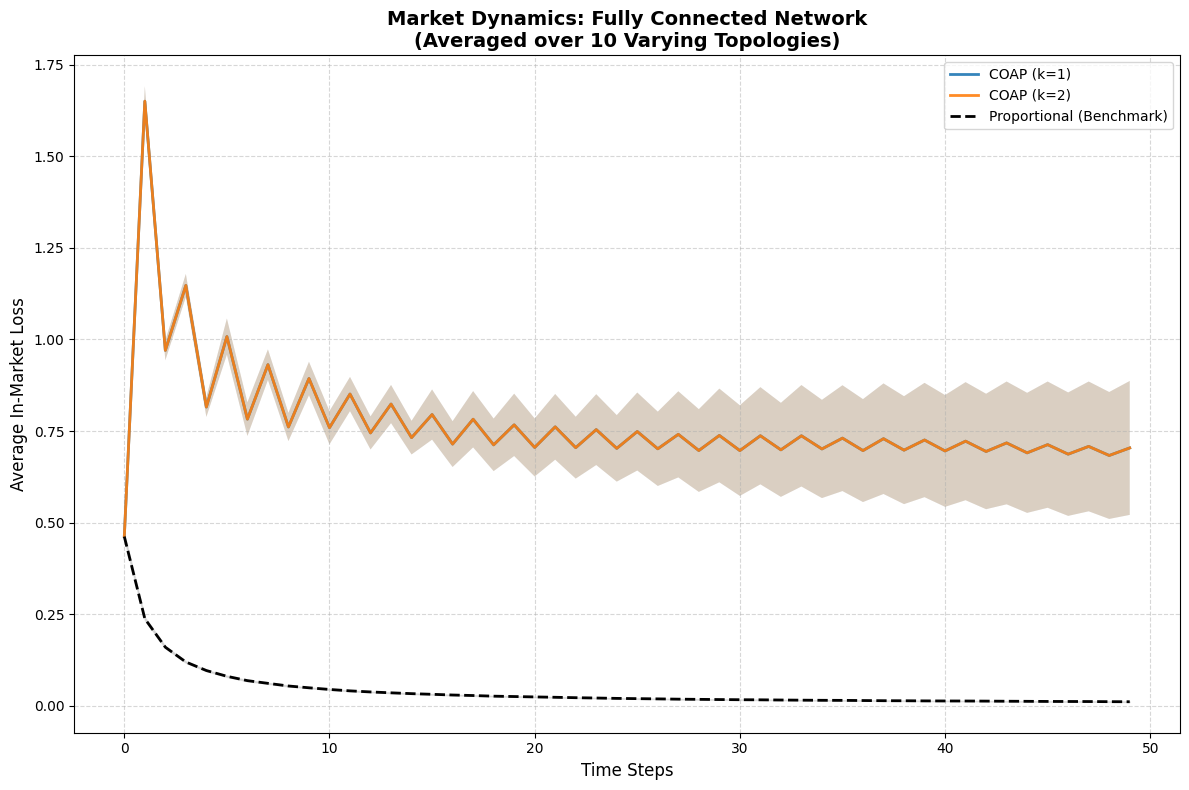


--- Summary Stats for Fully Connected ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.7039          0.1828          96.00%
COAP            2     0.7039          0.1828          96.00%
Proportional    -     0.0108          0.0005          100.00%


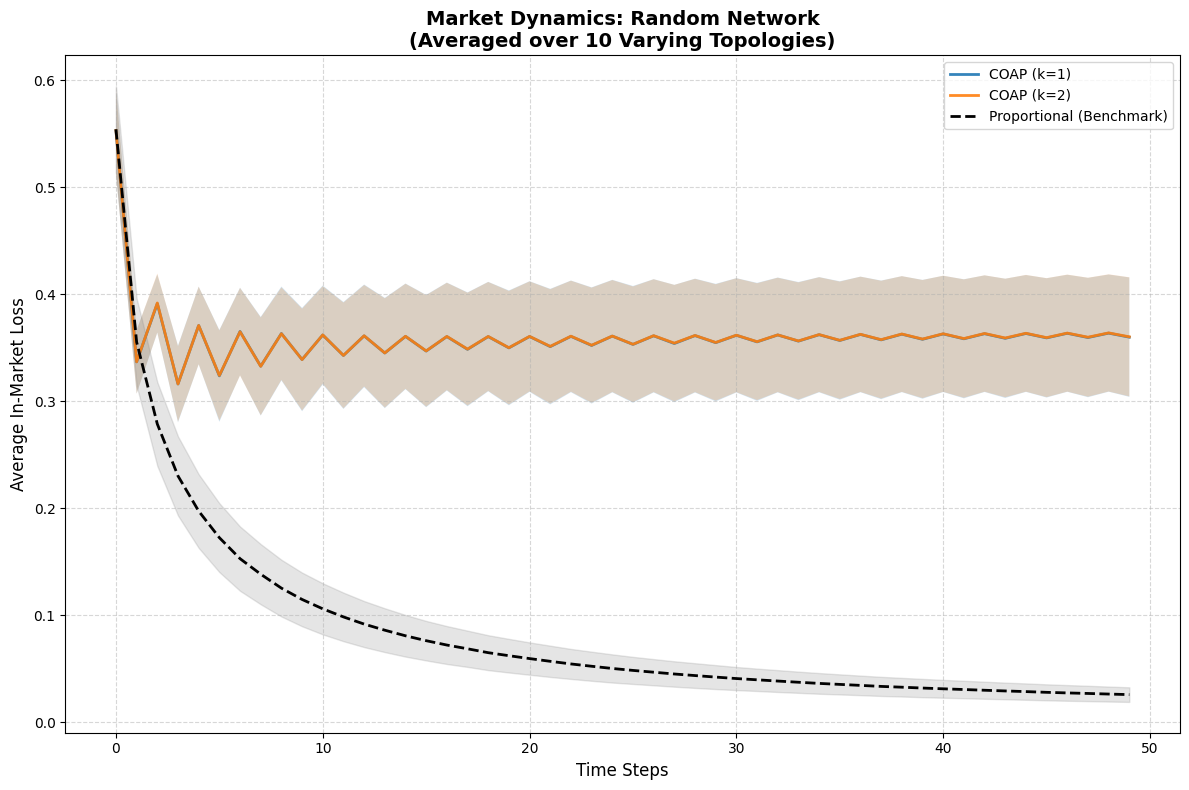


--- Summary Stats for Random ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.3599          0.0558          100.00%
COAP            2     0.3602          0.0557          100.00%
Proportional    -     0.0257          0.0068          100.00%


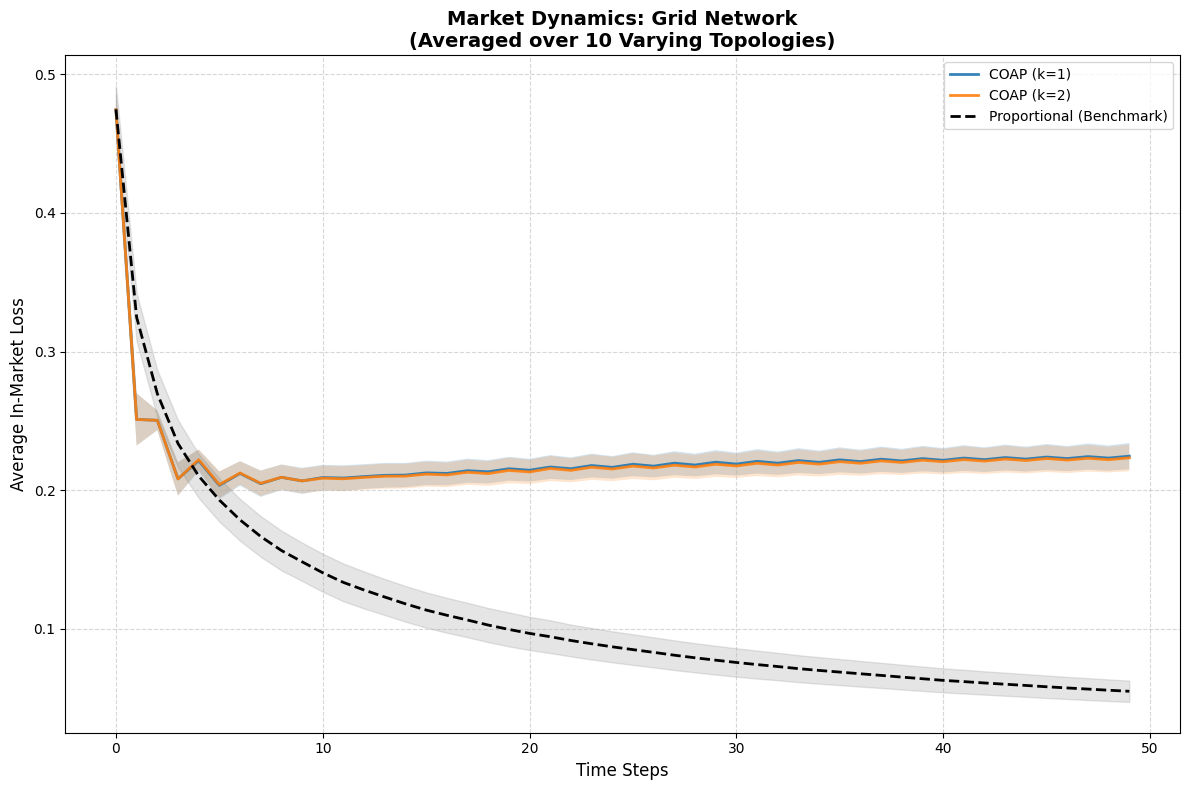


--- Summary Stats for Grid ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.2246          0.0095          100.00%
COAP            2     0.2234          0.0096          100.00%
Proportional    -     0.0551          0.0077          100.00%


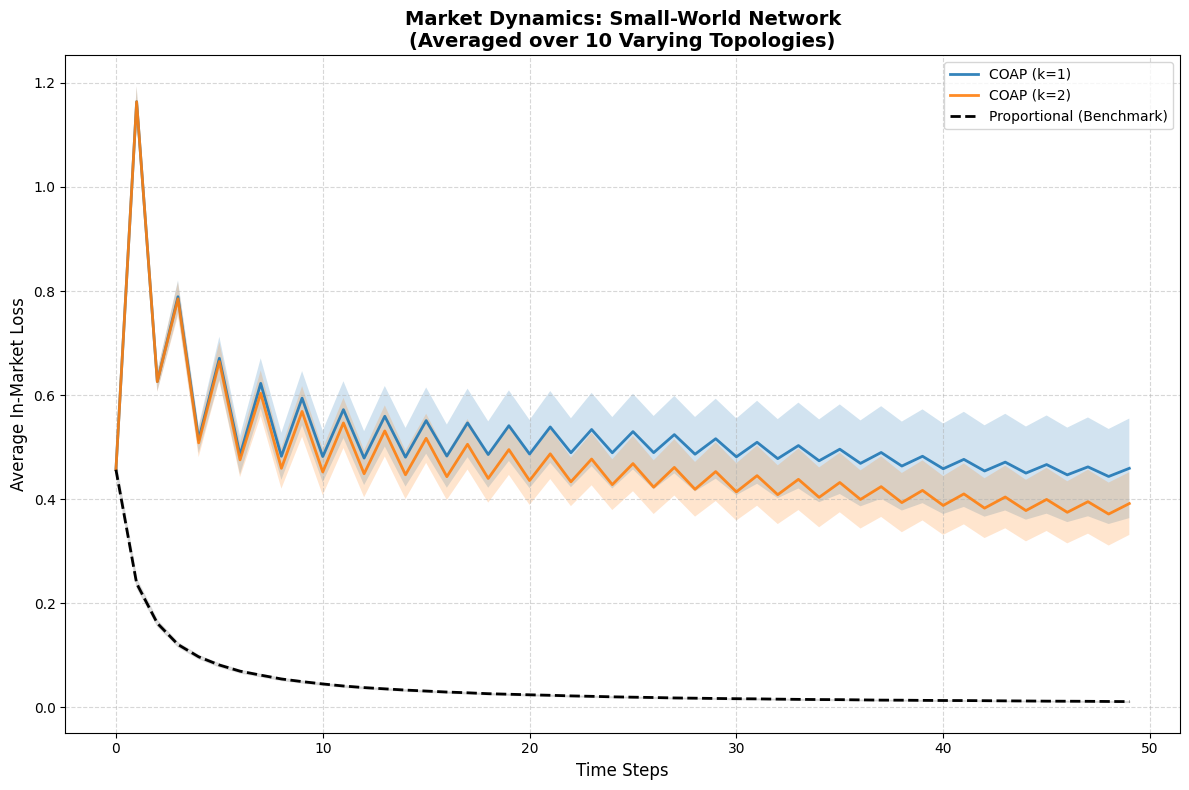


--- Summary Stats for Small-World ---
Strategy        K     Final Mean Loss Final Std Dev   Avg Health
------------------------------------------------------------
COAP            1     0.4592          0.0957          97.00%
COAP            2     0.3915          0.0603          100.00%
Proportional    -     0.0109          0.0007          100.00%

Simulation complete.


In [7]:
time_steps = np.arange(WINDOW_START, WINDOW_END)

print("\nGenerating Plots with Mean and Std Dev...")

for graph_type in results_store.keys():
    plt.figure(figsize=(12, 8))
    axis = plt.gca()
    
    # Plot COAP agents
    for k in KS:
        data_list = results_store[graph_type]["COAP"][k]
        
        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)
            
            
            label = f"COAP (k={k})"
            
            plt.plot(time_steps, mean_loss, label=label, alpha=0.9, linewidth=2)
            plt.fill_between(time_steps, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2)

    # Plot Benchmarks
    for bench in BENCHMARKS:
        data_list = results_store[graph_type][bench][None]
        if data_list:
            stacked_data = np.stack(data_list)
            mean_loss = np.mean(stacked_data, axis=0)
            std_loss = np.std(stacked_data, axis=0)
            
            label = f"{bench} (Benchmark)"
            
            plt.plot(time_steps, mean_loss, label=label, linestyle='--', color='black', linewidth=2)
            plt.fill_between(time_steps, mean_loss - std_loss, mean_loss + std_loss, alpha=0.2, color='gray')

    plt.xlabel("Time Steps", fontsize=12)
    plt.ylabel("Average In-Market Loss", fontsize=12)
    plt.title(f"Market Dynamics: {graph_type} Network\n(Averaged over {NUM_SEEDS} Varying Topologies)", fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

       # Optional: Print Summary Table for this graph type
    print(f"\n--- Summary Stats for {graph_type} ---")
    print(f"{'Strategy':<15} {'K':<5} {'Final Mean Loss':<15} {'Final Std Dev':<15} {'Avg Health'}")
    print("-" * 60)
    
    # COAP Agents
    for k in KS:
        data = results_store[graph_type]["COAP"][k]
        if data:
            # Ensure we take the last element of each seed run
            final_values = [d[-1] if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))
            final_std = float(np.std(final_values))
            avg_health = float(np.mean(crash_rates_store[graph_type]["COAP"][k]))
            print(f"{'COAP':<15} {str(k):<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}")
            
    # Benchmark Agents
    for bench in BENCHMARKS:
        data = results_store[graph_type][bench][None]
        if data:
            # Safety check to ensure data is numeric
            final_values = [float(d[-1]) if len(d) > 0 else 0.0 for d in data]
            final_mean = float(np.mean(final_values))
            # Benchmarks are usually deterministic, so std might be 0 or very small
            final_std = float(np.std(final_values)) 
            
            # Calculate health (usually 100% for proportional unless crashes happen)
            rates = crash_rates_store[graph_type][bench][None]
            avg_health = float(np.mean(rates)) if rates else 1.0
            
            # FIXED: Use explicit variable types to avoid format errors
            print(f"{bench:<15} {'-':<5} {final_mean:<15.4f} {final_std:<15.4f} {avg_health:.2%}")
        else:
            print(f"{bench:<15} {'-':<5} {'N/A':<15} {'N/A':<15} {'N/A':<10}")

print("\nSimulation complete.")